# Employee Performance and Productivity: Deep Learning Final Project

This notebook upgrades the original Machine Learning project into a Deep Learning project.

**Project:** Employee resignation risk prediction using the Extended Employee Performance and Productivity dataset.

**Deep Learning concepts used:**

- ANN with Batch Normalization, Dropout and L2 Regularization
- 1D CNN for tabular feature extraction
- Activation function comparison: ReLU, LeakyReLU, ELU and Tanh
- Optimizer comparison: Adam, SGD, RMSprop and Adagrad
- EarlyStopping, ReduceLROnPlateau style LR control and ModelCheckpoint
- FastAPI web app deployment

In [19]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(2)
np.random.seed(42)
torch.manual_seed(42)

## 1. Load the Dataset

In [20]:
possible_paths = [
    r"C:\Users\User\OneDrive\Desktop\Extended_Employee_Performance_and_Productivity_Data.csv",
    "Extended_Employee_Performance_and_Productivity_Data.csv",
    "data/Extended_Employee_Performance_and_Productivity_Data.csv",
    "/mnt/data/Extended_Employee_Performance_and_Productivity_Data.csv"
]

for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break
else:
    raise FileNotFoundError("Dataset not found. Put the CSV file in the project folder or data folder.")

data = pd.read_csv(DATA_PATH)
print("Original dataset shape:", data.shape)
data.head()

Original dataset shape: (100000, 20)


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years,Education,Performance,Salary,Work Hours,Projects Handled,Overtime,Sick_Days,Remote Freq,Team_Size,Training_Hours,Promotions,Satisfaction Score,Resigned
0,1,IT,Male,55,Specialist,03:05.6,2,High School,5,6750,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,03:05.6,0,High School,5,7500,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,03:05.6,8,High School,3,5850,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,03:05.6,7,Bachelor,2,4800,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,03:05.6,3,Bachelor,2,4800,38,11,29,13,100,15,9,1,1.25,False


## 2. Data Understanding

In [21]:
print(data.info())

print("\nMissing values:")
print(data.isnull().sum())

print("\nTarget distribution:")
print(data['Resigned'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Employee_ID         100000 non-null  int64  
 1   Department          100000 non-null  object 
 2   Gender              100000 non-null  object 
 3   Age                 100000 non-null  int64  
 4   Job_Title           100000 non-null  object 
 5   Hire_Date           100000 non-null  object 
 6   Years               100000 non-null  int64  
 7   Education           100000 non-null  object 
 8   Performance         100000 non-null  int64  
 9   Salary              100000 non-null  int64  
 10  Work Hours          100000 non-null  int64  
 11  Projects Handled    100000 non-null  int64  
 12  Overtime            100000 non-null  int64  
 13  Sick_Days           100000 non-null  int64  
 14  Remote Freq         100000 non-null  int64  
 15  Team_Size           100000 non-null

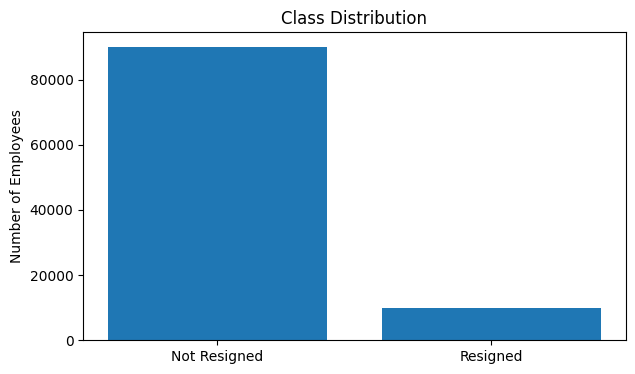

In [22]:
plt.figure(figsize=(7,4))
counts = data['Resigned'].map({False: 'Not Resigned', True: 'Resigned'}).value_counts()
plt.bar(counts.index, counts.values)
plt.title('Class Distribution')
plt.ylabel('Number of Employees')
plt.show()

## 3. Feature Selection

The original ML file predicted the `Resigned` column. I kept the same target and used employee profile, workload, performance and satisfaction columns as input features.

In [23]:
categorical_features = ['Department', 'Gender', 'Job_Title', 'Education']
numerical_features = [
    'Age', 'Years', 'Performance', 'Salary', 'Work Hours', 'Projects Handled',
    'Overtime', 'Sick_Days', 'Remote Freq', 'Team_Size', 'Training_Hours',
    'Promotions', 'Satisfaction Score'
]
features = categorical_features + numerical_features
target = 'Resigned'

# To keep training fast on normal laptops, I use a stratified 30k sample.
# The dataset is still the same project dataset. Increase MAX_ROWS or set it to None for full data.
MAX_ROWS = 30000
if MAX_ROWS is not None and len(data) > MAX_ROWS:
    data_model = data.groupby(target, group_keys=False).apply(
        lambda x: x.sample(frac=MAX_ROWS/len(data), random_state=42)
    ).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    data_model = data.copy()

X = data_model[features].copy()
y = data_model[target].astype(int)

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Rows used for training/testing:', data_model.shape)
print('Train shape:', X_train_df.shape)
print('Test shape:', X_test_df.shape)

Rows used for training/testing: (30000, 20)
Train shape: (24000, 17)
Test shape: (6000, 17)


## 4. Preprocessing

In [24]:
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', encoder, categorical_features)
])

X_train = preprocessor.fit_transform(X_train_df).astype(np.float32)
X_test = preprocessor.transform(X_test_df).astype(np.float32)
print('Input features after preprocessing:', X_train.shape[1])

Input features after preprocessing: 36


## 5. Machine Learning Baseline Models

In [25]:
def get_scores(name, probabilities):
    predictions = (probabilities >= 0.5).astype(int)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'ROC_AUC': roc_auc_score(y_test, probabilities),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1': f1_score(y_test, predictions, zero_division=0)
    }

results = []

logreg = LogisticRegression(max_iter=300, random_state=42)
logreg.fit(X_train, y_train)
results.append(get_scores('Logistic Regression', logreg.predict_proba(X_test)[:, 1]))

rf = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(get_scores('Random Forest', rf.predict_proba(X_test)[:, 1]))

pd.DataFrame(results)

,Model,Accuracy,ROC_AUC,Precision,Recall,F1
0,Logistic Regression,0.899833,0.506986,0.0,0.0,0.0
1,Random Forest,0.899833,0.510184,0.0,0.0,0.0


## 6. Prepare PyTorch Data

In [26]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.astype(np.float32), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.astype(np.float32), dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=512, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=1024, shuffle=False)
input_dim = X_train.shape[1]

## 7. ANN Model

In [27]:
class ANNClassifier(nn.Module):
    def __init__(self, input_dim, activation='relu'):
        super().__init__()
        activation_layers = {
            'relu': nn.ReLU(),
            'leakyrelu': nn.LeakyReLU(0.1),
            'elu': nn.ELU(),
            'tanh': nn.Tanh()
        }
        act = activation_layers[activation]
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            act,
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            act,
            nn.Dropout(0.20),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.network(x).squeeze(1)

## 8. Training Function with Callbacks

In [28]:
def evaluate_pytorch_model(model):
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            probs.extend(torch.sigmoid(logits).numpy())
    return np.array(probs)


def train_model(model, optimizer_name='adam', lr=0.001, epochs=6, checkpoint_path='best_model.pth', patience=3):
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    elif optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=1e-4)
    elif optimizer_name == 'adagrad':
        optimizer = torch.optim.Adagrad(model.parameters(), lr=lr, weight_decay=1e-4)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
    best_loss = np.inf
    bad_epochs = 0
    lr_wait = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses, val_probs, val_true = [], [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                logits = model(xb)
                val_losses.append(criterion(logits, yb).item())
                val_probs.extend(torch.sigmoid(logits).numpy())
                val_true.extend(yb.numpy())

        val_probs = np.array(val_probs)
        val_true = np.array(val_true)
        val_pred = (val_probs >= 0.5).astype(int)
        val_loss = np.mean(val_losses)
        val_acc = accuracy_score(val_true, val_pred)

        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {np.mean(train_losses):.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

        # ModelCheckpoint
        if val_loss < best_loss:
            best_loss = val_loss
            bad_epochs = 0
            lr_wait = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, checkpoint_path)
        else:
            bad_epochs += 1
            lr_wait += 1

        # ReduceLROnPlateau style
        if lr_wait >= 2:
            for group in optimizer.param_groups:
                group['lr'] *= 0.5
            print('Learning rate reduced.')
            lr_wait = 0

        # EarlyStopping
        if bad_epochs >= patience:
            print('Early stopping triggered.')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history

## 9. Train ANN

In [29]:
ann_model = ANNClassifier(input_dim, activation='relu')
ann_history = train_model(ann_model, optimizer_name='adam', lr=0.001, epochs=6, checkpoint_path='best_ann.pth')
ann_probs = evaluate_pytorch_model(ann_model)
results.append(get_scores('ANN + BatchNorm + Dropout', ann_probs))
pd.DataFrame(results)

Epoch 1/6 | Train Loss: 0.5297 | Val Loss: 0.4384 | Val Accuracy: 0.8998
Epoch 2/6 | Train Loss: 0.3604 | Val Loss: 0.3529 | Val Accuracy: 0.8998
Epoch 3/6 | Train Loss: 0.3318 | Val Loss: 0.3343 | Val Accuracy: 0.8998
Epoch 4/6 | Train Loss: 0.3276 | Val Loss: 0.3318 | Val Accuracy: 0.8998
Epoch 5/6 | Train Loss: 0.3272 | Val Loss: 0.3296 | Val Accuracy: 0.8998
Epoch 6/6 | Train Loss: 0.3243 | Val Loss: 0.3300 | Val Accuracy: 0.8998


,Model,Accuracy,ROC_AUC,Precision,Recall,F1
0,Logistic Regression,0.899833,0.506986,0.0,0.0,0.0
1,Random Forest,0.899833,0.510184,0.0,0.0,0.0
2,ANN + BatchNorm + Dropout,0.899833,0.518583,0.0,0.0,0.0


## 10. 1D CNN Model

In [30]:
class CNN1DClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Dropout(0.15),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(8)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_layers(x)
        return self.classifier(x).squeeze(1)

cnn_model = CNN1DClassifier(input_dim)
cnn_history = train_model(cnn_model, optimizer_name='adam', lr=0.001, epochs=4, checkpoint_path='best_cnn1d.pth')
cnn_probs = evaluate_pytorch_model(cnn_model)
results.append(get_scores('1D CNN', cnn_probs))
pd.DataFrame(results)

Epoch 1/4 | Train Loss: 0.3608 | Val Loss: 0.3314 | Val Accuracy: 0.8998
Epoch 2/4 | Train Loss: 0.3306 | Val Loss: 0.3286 | Val Accuracy: 0.8998
Epoch 3/4 | Train Loss: 0.3296 | Val Loss: 0.3279 | Val Accuracy: 0.8998
Epoch 4/4 | Train Loss: 0.3272 | Val Loss: 0.3268 | Val Accuracy: 0.8998


,Model,Accuracy,ROC_AUC,Precision,Recall,F1
0,Logistic Regression,0.899833,0.506986,0.0,0.0,0.0
1,Random Forest,0.899833,0.510184,0.0,0.0,0.0
2,ANN + BatchNorm + Dropout,0.899833,0.518583,0.0,0.0,0.0
3,1D CNN,0.899833,0.501335,0.0,0.0,0.0


## 11. Activation Function Comparison

In [31]:
activation_results = []

for activation in ['relu', 'leakyrelu', 'elu', 'tanh']:
    print('\nActivation:', activation)
    temp_model = ANNClassifier(input_dim, activation=activation)
    train_model(temp_model, optimizer_name='adam', lr=0.001, epochs=2, checkpoint_path=f'{activation}_model.pth', patience=2)
    probs = evaluate_pytorch_model(temp_model)
    activation_results.append({
        'Activation': activation,
        'Accuracy': accuracy_score(y_test, (probs >= 0.5).astype(int)),
        'ROC_AUC': roc_auc_score(y_test, probs)
    })

pd.DataFrame(activation_results)


Activation: relu
Epoch 1/2 | Train Loss: 0.6196 | Val Loss: 0.4926 | Val Accuracy: 0.8998
Epoch 2/2 | Train Loss: 0.3857 | Val Loss: 0.3716 | Val Accuracy: 0.8998

Activation: leakyrelu
Epoch 1/2 | Train Loss: 0.5313 | Val Loss: 0.4406 | Val Accuracy: 0.8998
Epoch 2/2 | Train Loss: 0.3644 | Val Loss: 0.3577 | Val Accuracy: 0.8998

Activation: elu
Epoch 1/2 | Train Loss: 0.6022 | Val Loss: 0.5320 | Val Accuracy: 0.8992
Epoch 2/2 | Train Loss: 0.4365 | Val Loss: 0.3964 | Val Accuracy: 0.8998

Activation: tanh
Epoch 1/2 | Train Loss: 0.7071 | Val Loss: 0.6582 | Val Accuracy: 0.6987
Epoch 2/2 | Train Loss: 0.5996 | Val Loss: 0.4875 | Val Accuracy: 0.8998


,Activation,Accuracy,ROC_AUC
0,relu,0.899833,0.506809
1,leakyrelu,0.899833,0.514446
2,elu,0.899833,0.505205
3,tanh,0.899833,0.499748


## 12. Optimizer Comparison

In [33]:
optimizer_results = []

for optimizer_name in ['adam', 'sgd', 'rmsprop', 'adagrad']:
    print('\nOptimizer:', optimizer_name)
    temp_model = ANNClassifier(input_dim, activation='relu')
    lr = 0.001 if optimizer_name != 'sgd' else 0.01
    train_model(temp_model, optimizer_name=optimizer_name, lr=lr, epochs=2, checkpoint_path=f'{optimizer_name}_model.pth', patience=2)
    probs = evaluate_pytorch_model(temp_model)
    optimizer_results.append({
        'Optimizer': optimizer_name,
        'Accuracy': accuracy_score(y_test, (probs >= 0.5).astype(int)),
        'ROC_AUC': roc_auc_score(y_test, probs)
    })

pd.DataFrame(optimizer_results)


Optimizer: adam
Epoch 1/2 | Train Loss: 0.4884 | Val Loss: 0.4180 | Val Accuracy: 0.8998
Epoch 2/2 | Train Loss: 0.3476 | Val Loss: 0.3432 | Val Accuracy: 0.8998

Optimizer: sgd
Epoch 1/2 | Train Loss: 0.3927 | Val Loss: 0.3361 | Val Accuracy: 0.8998
Epoch 2/2 | Train Loss: 0.3359 | Val Loss: 0.3376 | Val Accuracy: 0.8998

Optimizer: rmsprop
Epoch 1/2 | Train Loss: 0.3907 | Val Loss: 0.3463 | Val Accuracy: 0.8998
Epoch 2/2 | Train Loss: 0.3320 | Val Loss: 0.3317 | Val Accuracy: 0.8998

Optimizer: adagrad
Epoch 1/2 | Train Loss: 0.5311 | Val Loss: 0.5221 | Val Accuracy: 0.8990
Epoch 2/2 | Train Loss: 0.4765 | Val Loss: 0.4857 | Val Accuracy: 0.8998


,Optimizer,Accuracy,ROC_AUC
0,adam,0.899833,0.505732
1,sgd,0.899833,0.497667
2,rmsprop,0.899833,0.501568
3,adagrad,0.899833,0.494604


## 13. Final Model Comparison and Visualization

In [34]:
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
results_df

,Model,Accuracy,ROC_AUC,Precision,Recall,F1
0,Logistic Regression,0.899833,0.506986,0.0,0.0,0.0
1,Random Forest,0.899833,0.510184,0.0,0.0,0.0
2,ANN + BatchNorm + Dropout,0.899833,0.518583,0.0,0.0,0.0
3,1D CNN,0.899833,0.501335,0.0,0.0,0.0


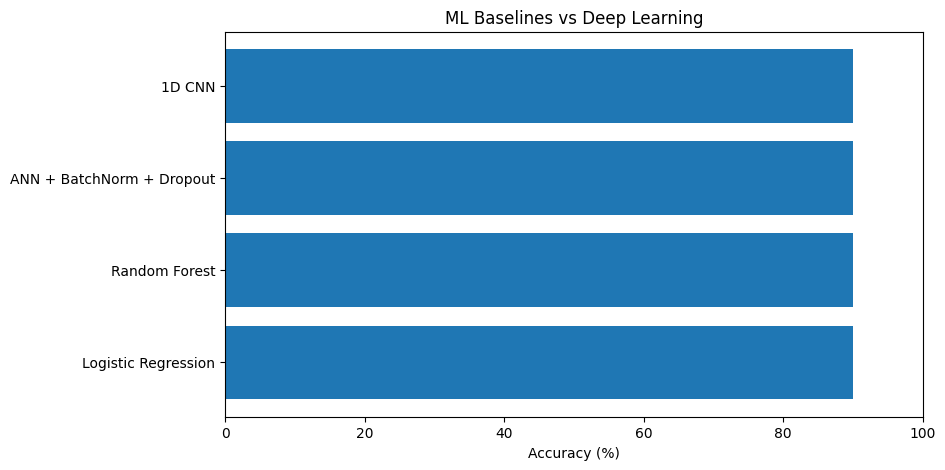

In [35]:
plt.figure(figsize=(9,5))
plt.barh(results_df['Model'], results_df['Accuracy'] * 100)
plt.xlabel('Accuracy (%)')
plt.title('ML Baselines vs Deep Learning')
plt.xlim(0, 100)
plt.show()

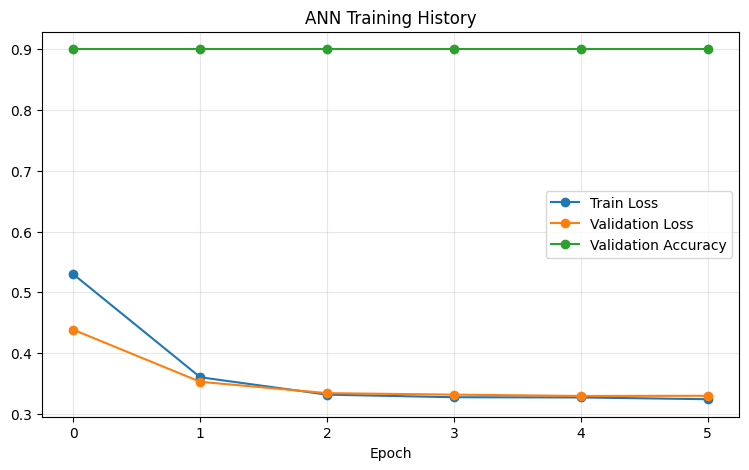

In [36]:
plt.figure(figsize=(9,5))
plt.plot(ann_history['train_loss'], marker='o', label='Train Loss')
plt.plot(ann_history['val_loss'], marker='o', label='Validation Loss')
plt.plot(ann_history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('ANN Training History')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 14. Save Model for Web App

In [37]:
os.makedirs('models', exist_ok=True)
joblib.dump(preprocessor, 'models/preprocessor.pkl')
torch.save(ann_model.state_dict(), 'models/best_ann.pth')

metadata = {
    'input_dim': int(input_dim),
    'features': features,
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'ann_accuracy': float(results_df[results_df['Model'] == 'ANN + BatchNorm + Dropout']['Accuracy'].iloc[0]),
    'ann_auc': float(results_df[results_df['Model'] == 'ANN + BatchNorm + Dropout']['ROC_AUC'].iloc[0])
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Saved model, metadata and preprocessor.')

Saved model, metadata and preprocessor.


## 15. Web App

The project folder includes a completed `app.py` file.

Run it using:

```bash
pip install -r requirements.txt
python app.py
```

Then open:

```text
http://127.0.0.1:5000
```

## 16. Conclusion

This project upgrades the previous Random Forest based ML task into a Deep Learning project. I implemented ANN, 1D CNN, activation function comparison, optimizer comparison, callbacks, model saving and a FastAPI dashboard app.

Note: the target column is imbalanced, so accuracy should be read together with ROC-AUC and class distribution.